# CMIP Projections

The 5 parameter sets calculkated in Calibration_HBV.ipynb will be used for a validation period, in which the log NSE will be calculated, a mean will be calculated and total low flow days during the navigation season.

The structure of this notebook is as follows:

### 1. Startup & Imports
### 2. Model setup
### 3. Lowflow setup
### 4. Running model
### 5. Lowflow data visualisation
### 6. Forcing data comparison & visualisation
### 7. Algorithm checker (freshet, freeze up dates)

## 1. Startup & Imports

In [80]:
# Imports

# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.interpolate import interp1d

# Niceties
from rich import print

In [81]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [82]:
# Defining things

basin_size = 132572
q_critical = 500

start_year = 2025
end_year = 2050

In [112]:
scenarios = ["ssp126", "ssp245", "ssp370"]

periods = [[2025, 2050, 2075],
           [2050, 2075, 2099]]

hist_periods = ([1989], [2014]) 

In [173]:
# Create pathways

def forcing_path_cmip(scenario, start_year, end_year):
    
    forcing_path = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}"
    
    return forcing_path

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [85]:
# Adjust time period

validation_start = f"{start_year}-01-01T00:00:00Z"
validation_end = f"{end_year}-12-31T00:00:00Z"

# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

## 2. Model setup

For running the model, the following steps are taken:

##### 2.1 Load parameter sets & initial storages
##### 2.2 Model configuration
##### 2.3 Model setup run

### 2.1 Load parameter sets & initial storages

In [86]:
# Define parameter ensemble

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]
]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"          # Snowmelt factor
               ]

In [87]:
# Define initial storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

### 2.2 Model configuration

In [88]:
# Model setup create function

def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config
    )

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge"
    )

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

### 2.3 Model setup run

In [89]:
# Model running create function

def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing
        )

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)

    return ensemble_data

## 3. Lowflow setup

Before running the model, the way lowflows are counted must be defined. this is so these functions can be called for every model run under every parameter set, scenario type and time period. The following steps are taken:

##### 3.1 Lowflow counter for the future
##### 3.2 Lowflow counter for observed data

### 3.1 Lowflow counter for the future 

In [90]:
def lowflow_counter_future(ensemble_data, start_date, end_date):

    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):

        year = years[i]

        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")

        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)
        ]

        modelled_lowflow_days = []

        # Count parameter set low-flow days
        for j in range(len(par_ensemble)):

            set_lowflow_days = 0

            for k in range(len(year_data)):

                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)

        lowflow_days.append({
            "year": year,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)
        })

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

### 3.2 Lowflow counter for observed data

In [91]:
def observed_lowflow_days(start_year=2000, end_year=2025):

    observed_lowflows = []

    q_obs = pd.read_csv(discharge_file, skiprows=1)
    q_obs = q_obs[["Date", "Value"]].copy()
    q_obs["Date"] = pd.to_datetime(q_obs["Date"])
    q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

    for year in range(start_year, end_year + 1):

        season_start = pd.to_datetime(f"{year}-05-18")
        season_end = pd.to_datetime(f"{year}-10-17")

        year_data = q_obs[
            (q_obs["Date"] >= season_start) &
            (q_obs["Date"] <= season_end)
        ]

        lowflow_days = (year_data["discharge_m3s"] < q_critical).sum()

        observed_lowflows.append({
            "year": year,
            "observed_lowflow_days": lowflow_days
        })

    observed_lowflows = pd.DataFrame(observed_lowflows)

    observed_average = round(observed_lowflows["observed_lowflow_days"].mean())
    observed_total = observed_lowflows["observed_lowflow_days"].sum()

    print("Observed average low-flow days/year:", observed_average)
    print("Observed total low-flow days:", observed_total)

    return observed_lowflows, observed_average

In [92]:
observed_lowflows, observed_avg = observed_lowflow_days(
    start_year=2000,
    end_year=2025
)

Observed average low-flow days/year: 27

Observed total low-flow days: 703

## 4. Running model

The previous functions in 2. and 3. will be used to run the model for every possible scenario and calculate the lowflows. The following steps are taken:

##### 4.1 Function for running one projection
##### 4.2 Running for every projection and store the data 

### 4.1 Function for running one projection

In [93]:
def run_one_projection(scenario, start_year, end_year):

    print(f"Running {scenario}, {start_year}-{end_year}")

    forcing_path = forcing_path_cmip(
        scenario=scenario,
        start_year=start_year,
        end_year=end_year
    )

    CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
        directory=forcing_path
    )

    ensemble_data = run_hbv_ensemble(
        par_ensemble=par_ensemble,
        initial_storages=s_0,
        forcing=CMIP_forcing
    )

    lowflow_table = lowflow_counter_future(
        ensemble_data=ensemble_data,
        start_date=pd.to_datetime(f"{start_year}-01-01"),
        end_date=pd.to_datetime(f"{end_year}-12-31")
    )

    return ensemble_data, lowflow_table

### 4.2 Running for every projection and store the data 

In [113]:
projection_data = {}
use_periods = []

for scenario in scenarios:

    # if scenario == "historical":
    #     use_periods = hist_periods
    # else:
    #     use_periods = periods

    for i in range(len(periods[0])):

        start_year = periods[0][i]
        end_year = periods[1][i]

        key = f"{scenario}_{start_year}_{end_year}"

        ensemble_data, lowflow_table = run_one_projection(scenario=scenario, start_year=start_year, end_year=end_year)

        projection_data[key] = {
            "ensemble": ensemble_data,
            "lowflow": lowflow_table
        }

Running ssp126, 2025-2050

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

...

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

## 5. Lowflow data visualisation

All the results have been ran and calculated in previous chapters. Here results are presented. First a table will be created showing lowflow days for 25 year periods from 2000-2100 under various climate scenarios. Second, a CDF distribution will be shown:

##### 5.1 Lowflow table
##### 5.2 CDF
##### 5.3 Quantiles

### 5.1 Lowflow table

In [95]:
def create_lowflow_summary_table(projection_data, scenarios, periods):

    rows = []

    for scenario in scenarios:

        row = {"scenario": scenario}

        row["Observed 2000-2025"] = round(observed_avg)

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            period_name = f"{start_year}-{end_year}"

            lowflow_table = projection_data[key]["lowflow"]

            row[period_name] = round(lowflow_table["set_avg"].mean())

        rows.append(row)

    return pd.DataFrame(rows)

In [114]:
summary_table = create_lowflow_summary_table(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods
)

summary_table

,scenario,Observed 2000-2025,2025-2050,2050-2075,2075-2099
0,ssp126,27,36,38,35
1,ssp245,27,40,38,31
2,ssp370,27,34,45,49


### 5.2 CDF 

In [99]:
def plot_cdf(projection_data, scenarios, periods):

    plt.figure(figsize=(8, 5))

    # Observed CDF
    observed_values = np.sort(observed_lowflows["observed_lowflow_days"].values)
    observed_cdf = np.arange(1, len(observed_values) + 1) / len(observed_values)

    plt.plot(observed_values,observed_cdf,marker="o",label="Observed 2000-2025")

    # Scenario CDFs
    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"

            lowflow_table = projection_data[key]["lowflow"]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = np.sort(all_lowflows)
        cdf = np.arange(1, len(values) + 1) / len(values)

        plt.plot(values,cdf,marker="o",label=scenario)

    plt.xlabel("Annual low-flow days")
    plt.ylabel("Cumulative probability")
    plt.title("CDF of annual low-flow days")
    plt.grid(True)
    plt.legend()
    plt.show()

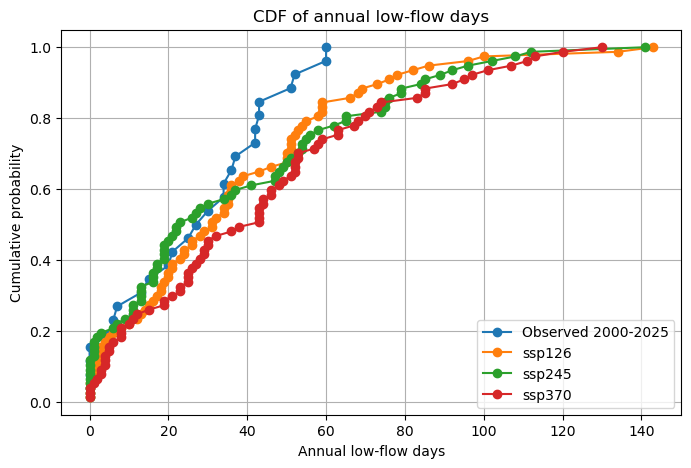

In [100]:
plot_cdf(
    projection_data=projection_data,
    scenarios=scenarios,
    periods=periods,
)

### 5.3 Quantiles

In [105]:
def lowflow_quantile_table(lowflow_results, scenarios, periods):

    rows = []

    for scenario in scenarios:

        all_lowflows = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            key = f"{scenario}_{start_year}_{end_year}"
            
            lowflow_table = lowflow_results[key]["lowflow"]

            all_lowflows.extend(lowflow_table["set_avg"].values)

        values = pd.Series(all_lowflows)

        rows.append({
            "scenario": scenario,
            "mean": round(values.mean(), 1),
            "median": values.median(),
            "p50": values.quantile(0.5),
            "p75": values.quantile(0.75),
            "p90": values.quantile(0.90),
            "max": values.max()
        })

    return pd.DataFrame(rows)

In [106]:
lowflow_quantile_table(projection_data, scenarios, periods)

,scenario,mean,median,p50,p75,p90,max
0,ssp126,36.1,31.0,31.0,52.0,74.2,143.0
1,ssp245,36.6,23.0,23.0,56.0,84.4,141.0
2,ssp370,42.8,43.0,43.0,63.0,93.2,130.0


# 6. Forcing data comparison & visualisation

Here the forcing data will be analysed. First the forcing files will be loaded in and merged for each scenario. Then, units will be converted. Finally, yearly and period averages will be calculated and saved in lists. This will be used in 6.2 and 6.3 for visualisation.

##### 6.1 Loading and preparing forcing data
##### 6.2 Period forcing avg table
##### 6.3 Yearly forcing avg graph

### 6.3 Loading and preparing forcing data

In [125]:
var_names = {"evspsblpot", "pr", "rsds", "tas"}

forcing_data = {}
annual_avg = []
period_avg = []

for scenario in scenarios:

    forcing_data[scenario] = {}

    for var_name in var_names:

        merged_data_list = []

        for i in range(len(periods[0])):

            start_year = periods[0][i]
            end_year = periods[1][i]

            # Define file path
            forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"
            
            # Load file as dataset
            ds = xr.open_dataset(forcing_file)

            # Load file as array
            da = ds[var_name]

            # Convert to series 
            series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

            # Convert pr and evap from km^2/s to mm^2/day
            if var_name in ["pr", "evspsblpot"]:
                series = series * 86400
                annual = series.groupby(series.index.year).sum()

            # Convert temp from Kelvin to Celcius
            elif var_name == "tas":
                series = series - 273.15
                annual = series.groupby(series.index.year).mean()

            elif var_name == "rsds":
                annual = series.groupby(series.index.year).mean()

            # Save for merged time series
            merged_data_list.append(series)

            # Save annual values
            for year, annual_value in annual.items():

                annual_avg.append({"scenario": scenario,
                                    "period": f"{start_year}-{end_year}",
                                    "year": year,
                                    "variable": var_name,
                                    "value": annual_value})

            # Save 25 year average
            period_avg.append({"scenario": scenario,
                                "period": f"{start_year}-{end_year}",
                                "variable": var_name,
                                "value": annual.mean()})

        # Merge periods into one 2025–2099 series
        merged_data = pd.concat(merged_data_list)
        merged_data = merged_data[~merged_data.index.duplicated(keep="first")]
        merged_data = merged_data.sort_index()

        forcing_data[scenario][var_name] = merged_data

# Create summary table for annual avg values
annual_table = pd.DataFrame(annual_avg)

# Create summary table for period avg values
period_table = pd.DataFrame(period_avg).pivot_table(index=["scenario", "period"],columns="variable",values="value")

In [178]:
# Prepare historical data

def load_hist(start_year, end_year):

    scenario = "historical"
    annual_avg = []

    for var_name in var_names:

        merged_data_list = []
    
        forcing_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" / "Workyard" / "forcings" / "CMIP6" / scenario / f"CMIP6-{start_year}-{end_year}" / f"combined_CMIP6_{start_year}_{end_year}_{var_name}.nc"

        # Load file as dataset
        ds = xr.open_dataset(forcing_file)

        # Load file as array
        da = ds[var_name]

        # Convert to series 
        series = pd.Series(data=da.values.squeeze(),index=pd.to_datetime(da["time"].values).normalize(),name=var_name)

        # Convert pr and evap from km^2/s to mm^2/day
        if var_name in ["pr", "evspsblpot"]:
            series = series * 86400
            annual = series.groupby(series.index.year).sum()

        # Convert temp from Kelvin to Celcius
        elif var_name == "tas":
            series = series - 273.15
            annual = series.groupby(series.index.year).mean()

        elif var_name == "rsds":
            annual = series.groupby(series.index.year).mean()

                    # Save for merged time series
            merged_data_list.append(series)

        # Save annual values
        for year, annual_value in annual.items():

            annual_avg.append({"scenario": scenario,
                                "period": f"{start_year}-{end_year}",
                                "year": year,
                                "variable": var_name,
                                "value": annual_value})
            
    annual_hist_table = pd.DataFrame(annual_avg)
    
    return annual_hist_table

In [180]:
annual_hist_table = load_hist(start_year=1989,end_year=2014)

annual_hist_table.head()

,scenario,period,year,variable,value
0,historical,1989-2014,1989,tas,2.562430
1,historical,1989-2014,1990,tas,1.319359
2,historical,1989-2014,1991,tas,1.052132
3,historical,1989-2014,1992,tas,0.776736
4,historical,1989-2014,1993,tas,1.499663


### 6.2 Period forcing avg table

In [127]:
def create_period_forcing_table(annual_table):

    period_forcing_table = (
        annual_forcing_table
        .groupby(["scenario", "period", "variable"])["value"]
        .mean()
        .reset_index()
    )

    period_forcing_table = period_forcing_table.pivot_table(
        index=["scenario", "period"],
        columns="variable",
        values="value"
    )

    return period_forcing_table

In [131]:
period_forcing_table = round(create_period_forcing_table(forcing_summary_table), 1)

period_forcing_table

variable            evspsblpot     pr   rsds  tas
scenario period                                  
ssp126   2025-2050       621.1  633.9  138.5  2.5
         2050-2075       625.8  630.1  138.7  3.0
         2075-2099       621.5  645.3  138.2  2.7
ssp245   2025-2050       628.0  623.0  139.5  2.7
         2050-2075       632.7  637.3  138.3  3.6
         2075-2099       635.6  659.8  137.8  3.6
ssp370   2025-2050       623.4  640.5  138.5  2.7
         2050-2075       636.3  650.3  136.7  4.4
         2075-2099       656.9  645.7  136.6  5.4

### 6.3 Yearly forcing avg graph

In [193]:
colours = {
    "historical": "black",
    "ssp126": "green",
    "ssp245": "blue",
    "ssp370": "orange"
}

scenarios_new = ["historical", "ssp126", "ssp245", "ssp370"]

def plot_annual_forcing_variable(annual_forcing_table, var_name):

    # Combine historical and scenarios
    annual_forcing_table_all = pd.concat([annual_hist_table, annual_forcing_table],ignore_index=True)

    data = annual_forcing_table_all[annual_forcing_table_all["variable"] == var_name]
    
    plt.figure(figsize=(9, 5))
    
    # Loop through scenarios
    for scenario in scenarios_new:

        scenario_data = data[data["scenario"] == scenario]
        colour = colours[scenario]

        if scenario == "historical":

            plt.plot(scenario_data["year"],scenario_data["value"],color=colour,linewidth=0.3,label=scenario)

            x = scenario_data["year"].values
            y = scenario_data["value"].values

            # Polyfit method for making trendline function
            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            # Plot
            plt.plot(x,trend,linestyle="--",color=colour)

        else:

            # Plot yearly data 
            plt.plot(scenario_data["year"],scenario_data["value"],alpha=0.3,color=colour,label=scenario)

        # Plot trendline for each period
        for i in range(len(periods[0])):

            # Define period range
            start_year = periods[0][i]
            end_year = periods[1][i]

            # Adjust data to fit period range
            period_data = scenario_data[(scenario_data["year"] >= start_year) & (scenario_data["year"] <= end_year)]

            # Plot trend line over each 25 year period
            if len(period_data) > 1:

                x = period_data["year"].values
                y = period_data["value"].values

                # Polyfit method for making trendline function
                slope, intercept = np.polyfit(x, y, 1)
                trend = slope * x + intercept

                # Plot
                plt.plot(x,trend,linestyle="--",color=colour)

    if var_name == "pr":
        ylabel = "Annual precipitation (mm/year)"
        title = "Annual precipitation in LAR basin by climate scenario"

    elif var_name == "evspsblpot":
        ylabel = "Annual potential evaporation (mm/year)"
        title = "Annual potential evaporation in LAR basin by climate scenario"

    elif var_name == "tas":
        ylabel = "Annual mean temperature increase (°C)"
        title = "Annual mean temperature in LAR basin by climate scenario"

    elif var_name == "rsds":
        ylabel = "Annual mean shortwave radiation (W/m²)"
        title = "Annual mean shortwave radiation in LAR basin by climate scenario"

    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

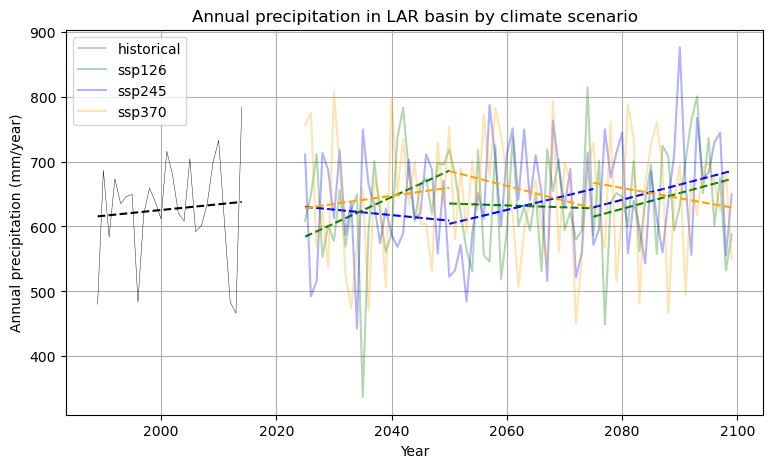

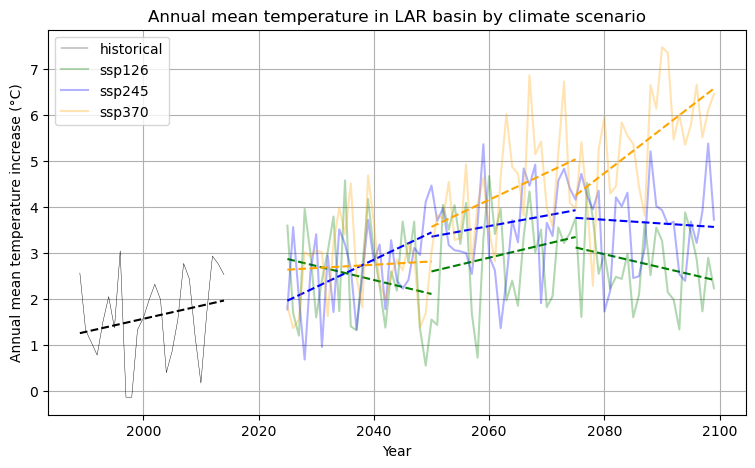

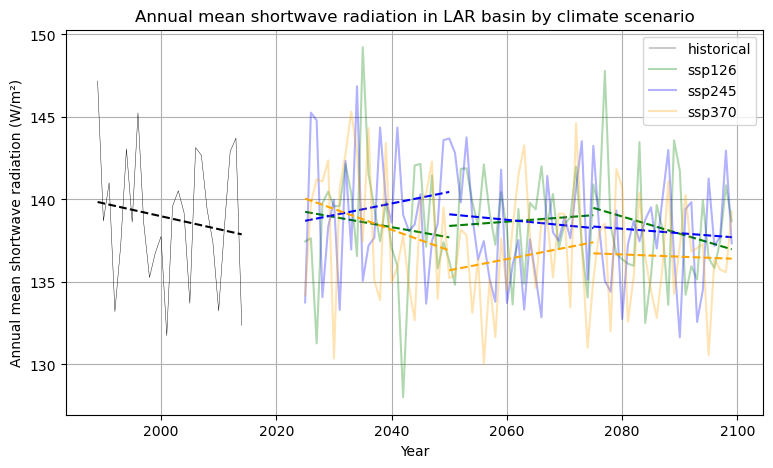

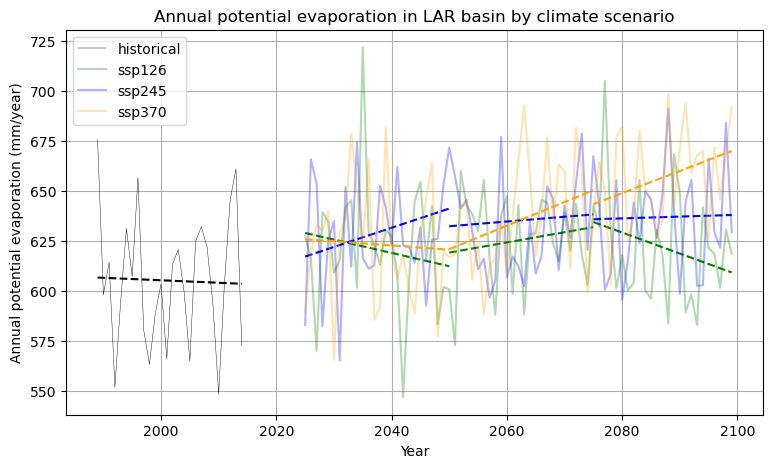

In [194]:
for var_name in ["pr", "tas", "rsds", "evspsblpot"]:
    plot_annual_forcing_variable(annual_forcing_table, var_name)

## 7. Algorithm checker

In [ ]:
selected_scenario = "ssp370"
start_year = 2075
end_year = 2099
AFDD_critical = 30

In [ ]:
forcing_path_CMIP = forcing_path_cmip(
    scenario=selected_scenario,
    start_year=start_year,
    end_year=end_year
)

CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
    directory=forcing_path_CMIP
)

ensemble_data_CMIP = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=CMIP_forcing
)

In [ ]:
def find_freshet_start_dates(ensemble_data, start_year, end_year):

    freshet_dates = []

    for year in range(start_year, end_year + 1):

        year_start = pd.to_datetime(f"{year}-03-01")
        year_end = pd.to_datetime(f"{year}-08-01")

        season_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)
        ]

        above_critical = season_data[season_data["Mean"] > q_critical]

        if len(above_critical) > 0:
            freshet_date = above_critical.index[0]
            discharge = above_critical.iloc[0]["Mean"]
        else:
            freshet_date = pd.NaT
            discharge = np.nan

        freshet_dates.append({
            "year": year,
            "freshet_start": freshet_date,
            "freshet_discharge": discharge
        })

    return pd.DataFrame(freshet_dates)

In [ ]:
def find_freezeup_dates(forcing_path, start_year, end_year, AFDD_critical=30):

    tas_da, _, _ = load_variable(forcing_path, "tas")

    tas = to_series(tas_da)

    if tas.mean() > 100:
        tas = tas - 273.15

    freezeup_dates = []

    for year in range(start_year, end_year + 1):

        year_start = pd.to_datetime(f"{year}-10-01")
        year_end = pd.to_datetime(f"{year}-12-31")

        year_tas = tas[
            (tas.index >= year_start) &
            (tas.index <= year_end)
        ]

        AFDD = 0
        freezeup_date = pd.NaT
        freezeup_temp = np.nan

        for date, temp in year_tas.items():

            if temp < 0:
                AFDD += -temp

            if AFDD >= AFDD_critical:
                freezeup_date = date
                freezeup_temp = temp
                break

        freezeup_dates.append({
            "year": year,
            "freezeup_date": freezeup_date,
            "AFDD": AFDD,
            "temp_at_freezeup": freezeup_temp
        })

    return pd.DataFrame(freezeup_dates)

In [ ]:
freshet_dates = find_freshet_start_dates(
    ensemble_data=ensemble_data_CMIP,
    start_year=start_year,
    end_year=end_year
)

freezeup_dates = find_freezeup_dates(
    forcing_path=forcing_path_CMIP,
    start_year=start_year,
    end_year=end_year,
    AFDD_critical=AFDD_critical
)

open_water_dates = freshet_dates.merge(
    freezeup_dates,
    on="year",
    how="inner"
)

open_water_dates["open_water_days"] = (
    open_water_dates["freezeup_date"] - open_water_dates["freshet_start"]
).dt.days

open_water_dates